In [ ]:
import sys 
print (sys.executable)

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import sklearn

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)

Pandas: 3.0.6
NumPy: 2.5.3
Matplotlib: 3.11.2
Scikit-learn: 1.9.1


In [2]:
import pandas as pd

df = pd.read_csv("../data/Tuesday-WorkingHours.pcap_ISCX.csv")

df.columns = df.columns.str.strip()

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (445909, 79)


In [3]:
print("Dataset shape:", df.shape)

print("\nColumn data types:")
print(df.dtypes.value_counts())

print("\nLabel distribution:")
print(df["Label"].value_counts())

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Dataset shape: (445909, 79)

Column data types:
int64      54
float64    24
str         1
Name: count, dtype: int64

Label distribution:
Label
BENIGN         432074
FTP-Patator      7938
SSH-Patator      5897
Name: count, dtype: int64

Missing values:
201

Duplicate rows:
24065


In [4]:
import numpy as np

# Handle missing values in Flow Bytes/s
df["Flow Bytes/s"] = df["Flow Bytes/s"].fillna(0)

# Remove duplicate rows
df = df.drop_duplicates()

# Remove invalid negative flow durations
df = df[df["Flow Duration"] >= 0].copy()

print("Cleaned dataset shape:", df.shape)
print("\nMissing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Negative Flow Duration:", (df["Flow Duration"] < 0).sum())

Cleaned dataset shape: (421828, 79)

Missing values: 0
Duplicate rows: 0
Negative Flow Duration: 0


In [5]:
# Create binary target
df["Target"] = df["Label"].apply(
    lambda x: 0 if x == "BENIGN" else 1
)

print("Target distribution:")
print(df["Target"].value_counts())

print("\nTarget meaning:")
print("0 = BENIGN")
print("1 = ATTACK")

Target distribution:
Target
0    412676
1      9152
Name: count, dtype: int64

Target meaning:
0 = BENIGN
1 = ATTACK


In [6]:
# Separate features and target

X = df.drop(columns=["Label", "Target"])
y = df["Target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nNumber of features:", X.shape[1])
print("Number of target values:", y.shape[0])

Features shape: (421828, 78)
Target shape: (421828,)

Number of features: 78
Number of target values: 421828


In [7]:
# Check for missing and infinite values in the features

print("Missing values in X:", X.isnull().sum().sum())

print("Infinite values in X:", np.isinf(X.to_numpy()).sum())

Missing values in X: 0
Infinite values in X: 275


In [8]:
# Replace infinite values with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Fill remaining missing values with the median of each feature
X = X.fillna(X.median())

# Verify
print("Missing values after cleaning:", X.isnull().sum().sum())
print("Infinite values after cleaning:", np.isinf(X.to_numpy()).sum())

Missing values after cleaning: 0
Infinite values after cleaning: 0


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training features: (337462, 78)
Testing features: (84366, 78)

Training target distribution:
Target
0    330140
1      7322
Name: count, dtype: int64

Testing target distribution:
Target
0    82536
1     1830
Name: count, dtype: int64


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (337462, 78)
Scaled testing shape: (84366, 78)


In [11]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [12]:
# Make predictions on the test data

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred_logistic))

Predictions generated successfully!
Number of predictions: 84366


In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Logistic Regression Results
---------------------------
Accuracy : 0.9987317165682859
Precision: 0.9705079191698526
Recall   : 0.9710382513661202
F1-score : 0.9707730128380224


In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_logistic)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[82482    54]
 [   53  1777]]


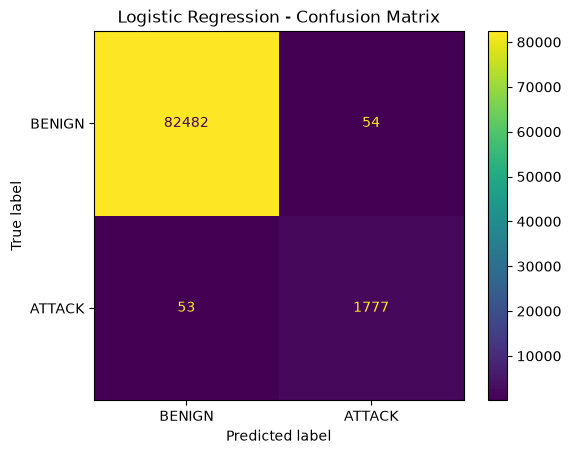

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["BENIGN", "ATTACK"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")

plt.savefig(
    "../results/graphs/logistic_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [17]:
# Make predictions using the Decision Tree

y_pred_tree = decision_tree_model.predict(X_test)

print("Decision Tree predictions generated successfully!")
print("Number of predictions:", len(y_pred_tree))

Decision Tree predictions generated successfully!
Number of predictions: 84366


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", accuracy_tree)
print("Precision:", precision_tree)
print("Recall   :", recall_tree)
print("F1-score :", f1_tree)

Decision Tree Results
---------------------
Accuracy : 0.9999407344190788
Precision: 0.9989065062875888
Recall   : 0.9983606557377049
F1-score : 0.9986335064225198


In [19]:
from sklearn.metrics import confusion_matrix

cm_tree = confusion_matrix(y_test, y_pred_tree)

print("Decision Tree Confusion Matrix:")
print(cm_tree)

Decision Tree Confusion Matrix:
[[82534     2]
 [    3  1827]]


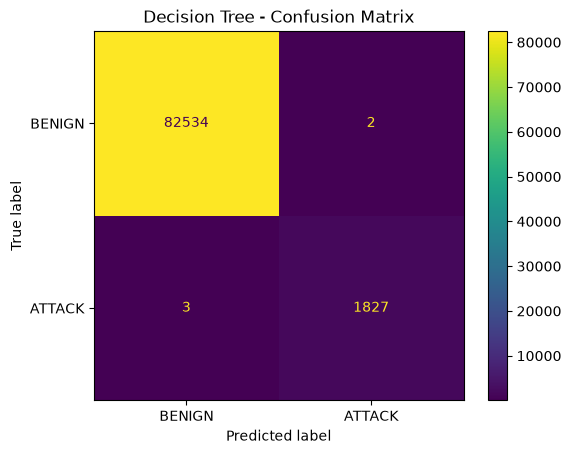

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["BENIGN", "ATTACK"]
)

disp.plot()
plt.title("Decision Tree - Confusion Matrix")

plt.savefig(
    "../results/graphs/decision_tree_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [22]:
# Make predictions using the Random Forest

y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest predictions generated successfully!")
print("Number of predictions:", len(y_pred_rf))

Random Forest predictions generated successfully!
Number of predictions: 84366


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1-score :", f1_rf)

Random Forest Results
---------------------
Accuracy : 0.9999525875352631
Precision: 1.0
Recall   : 0.9978142076502732
F1-score : 0.9989059080962801


In [24]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(cm_rf)

Random Forest Confusion Matrix:
[[82536     0]
 [    4  1826]]


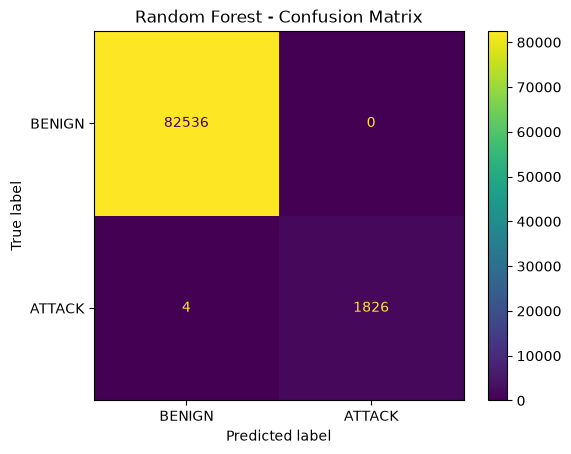

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["BENIGN", "ATTACK"]
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")

plt.savefig(
    "../results/graphs/random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_tree,
        accuracy_rf
    ],
    "Precision": [
        precision,
        precision_tree,
        precision_rf
    ],
    "Recall": [
        recall,
        recall_tree,
        recall_rf
    ],
    "F1-score": [
        f1,
        f1_tree,
        f1_rf
    ]
})

print(model_comparison.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1-score
Logistic Regression  0.998732   0.970508 0.971038  0.970773
      Decision Tree  0.999941   0.998907 0.998361  0.998634
      Random Forest  0.999953   1.000000 0.997814  0.998906


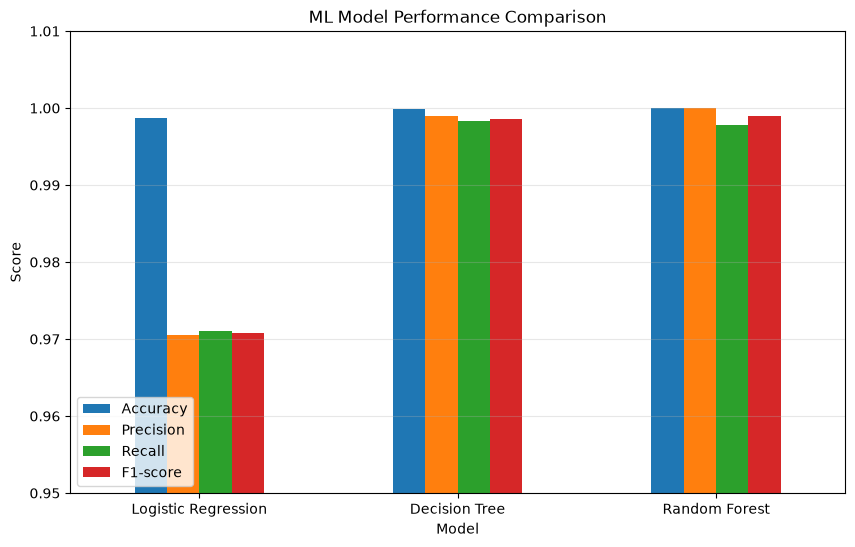

In [27]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

model_comparison.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("ML Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.95, 1.01)
plt.xticks(rotation=0)
plt.legend(loc="lower left")
plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "../results/graphs/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Important Features:")
print(feature_importance.head(15).to_string(index=False))

Top 15 Important Features:
               Feature  Importance
      Destination Port    0.174537
     Packet Length Std    0.045135
    Packet Length Mean    0.040081
   Average Packet Size    0.038552
Total Backward Packets    0.033048
  Avg Bwd Segment Size    0.031547
     Bwd Header Length    0.031269
Packet Length Variance    0.028791
Bwd Packet Length Mean    0.026660
 Fwd Packet Length Std    0.025671
          Flow IAT Max    0.024717
 Fwd Packet Length Max    0.023482
      act_data_pkt_fwd    0.021781
  Avg Fwd Segment Size    0.019109
           Bwd IAT Max    0.018811


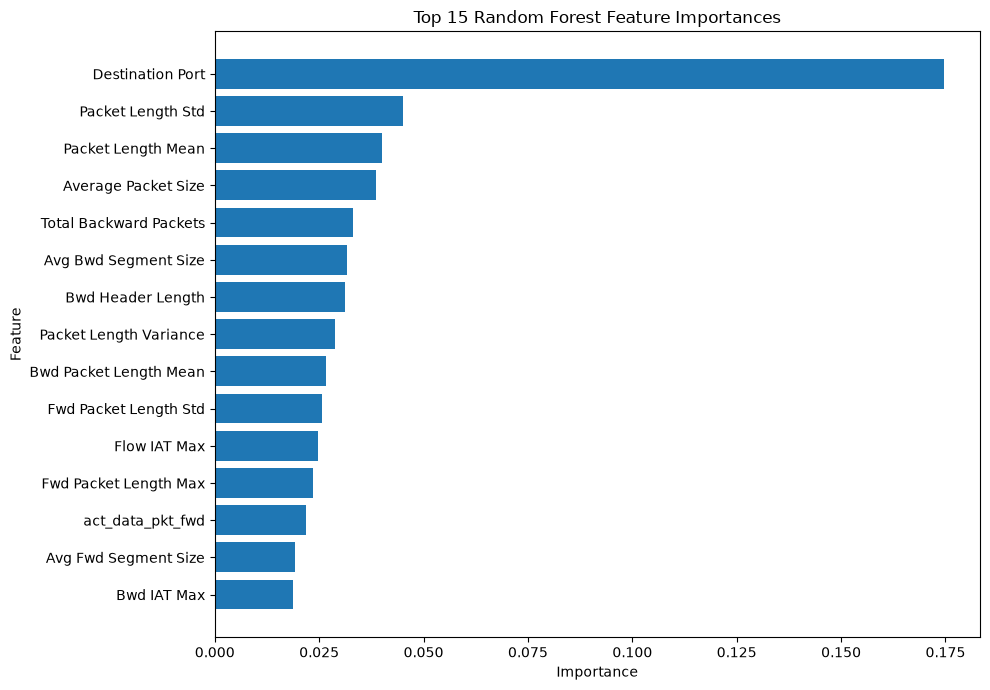

In [29]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")

plt.tight_layout()

plt.savefig(
    "../results/graphs/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
class_counts = y.value_counts()
class_percentages = y.value_counts(normalize=True) * 100

print("Class Distribution")
print("------------------")

for label in class_counts.index:
    class_name = "BENIGN" if label == 0 else "ATTACK"
    print(
        f"{class_name}: {class_counts[label]} "
        f"({class_percentages[label]:.2f}%)"
    )

Class Distribution
------------------
BENIGN: 412676 (97.83%)
ATTACK: 9152 (2.17%)


In [31]:
balanced_logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

balanced_logistic_model.fit(X_train_scaled, y_train)

print("Class-weighted Logistic Regression trained successfully!")

Class-weighted Logistic Regression trained successfully!


In [32]:
y_pred_balanced = balanced_logistic_model.predict(X_test_scaled)

print("Class-weighted Logistic Regression predictions generated successfully!")
print("Number of predictions:", len(y_pred_balanced))

Class-weighted Logistic Regression predictions generated successfully!
Number of predictions: 84366


In [33]:
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
precision_balanced = precision_score(y_test, y_pred_balanced)
recall_balanced = recall_score(y_test, y_pred_balanced)
f1_balanced = f1_score(y_test, y_pred_balanced)

print("Class-Weighted Logistic Regression Results")
print("-------------------------------------------")
print("Accuracy :", accuracy_balanced)
print("Precision:", precision_balanced)
print("Recall   :", recall_balanced)
print("F1-score :", f1_balanced)

Class-Weighted Logistic Regression Results
-------------------------------------------
Accuracy : 0.9902093260318138
Precision: 0.6900075700227101
Recall   : 0.9961748633879781
F1-score : 0.8152951699463328


In [34]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

print("Class-Weighted Logistic Regression Confusion Matrix:")
print(cm_balanced)

Class-Weighted Logistic Regression Confusion Matrix:
[[81717   819]
 [    7  1823]]


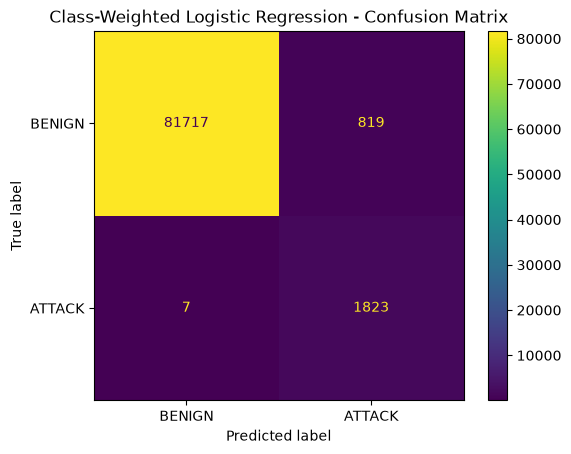

In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_balanced,
    display_labels=["BENIGN", "ATTACK"]
)

disp.plot()
plt.title("Class-Weighted Logistic Regression - Confusion Matrix")

plt.savefig(
    "../results/graphs/class_weighted_logistic_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
imbalance_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Class-Weighted Logistic Regression"
    ],
    "Accuracy": [
        accuracy,
        accuracy_balanced
    ],
    "Precision": [
        precision,
        precision_balanced
    ],
    "Recall": [
        recall,
        recall_balanced
    ],
    "F1-score": [
        f1,
        f1_balanced
    ]
})

print(imbalance_comparison.to_string(index=False))

                             Model  Accuracy  Precision   Recall  F1-score
               Logistic Regression  0.998732   0.970508 0.971038  0.970773
Class-Weighted Logistic Regression  0.990209   0.690008 0.996175  0.815295


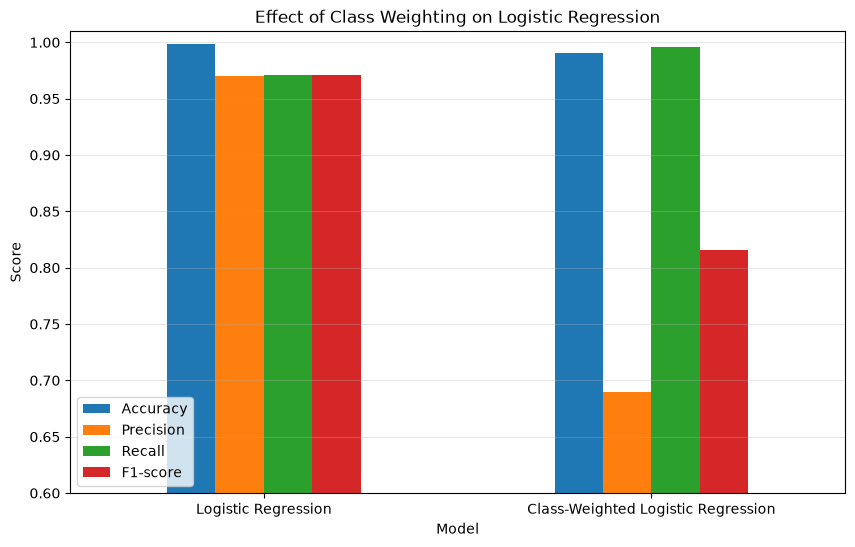

In [37]:
import matplotlib.pyplot as plt

imbalance_comparison.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Effect of Class Weighting on Logistic Regression")
plt.ylabel("Score")
plt.ylim(0.60, 1.01)
plt.xticks(rotation=0)
plt.legend(loc="lower left")
plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "../results/graphs/class_weighting_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
correlation_matrix = X_train.corr().abs()

# Get the upper triangle of the correlation matrix
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# Find feature pairs with correlation above 0.95
high_correlations = (
    upper_triangle
    .stack()
    .sort_values(ascending=False)
)

high_correlations = high_correlations[
    high_correlations > 0.95
]

print("Number of highly correlated feature pairs:", len(high_correlations))

print("\nTop highly correlated feature pairs:")
print(high_correlations.head(20))

Number of highly correlated feature pairs: 38

Top highly correlated feature pairs:
Total Length of Fwd Packets  Subflow Fwd Bytes              1.000000
Fwd Header Length            Fwd Header Length.1            1.000000
Total Fwd Packets            Subflow Fwd Packets            1.000000
Fwd Packet Length Mean       Avg Fwd Segment Size           1.000000
Total Backward Packets       Subflow Bwd Packets            1.000000
Fwd PSH Flags                SYN Flag Count                 1.000000
Bwd Packet Length Mean       Avg Bwd Segment Size           1.000000
Total Length of Bwd Packets  Subflow Bwd Bytes              1.000000
Total Fwd Packets            Subflow Bwd Packets            0.999513
Total Backward Packets       Subflow Fwd Packets            0.999513
Subflow Fwd Packets          Subflow Bwd Packets            0.999513
Total Fwd Packets            Total Backward Packets         0.999513
Flow Duration                Fwd IAT Total                  0.998436
Total Fwd Packets  

In [39]:
high_corr_df = high_correlations.reset_index()

high_corr_df.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

high_corr_df.to_csv(
    "../results/reports/highly_correlated_features.csv",
    index=False
)

print("Correlation analysis saved successfully!")
print("Saved to: results/reports/highly_correlated_features.csv")

Correlation analysis saved successfully!
Saved to: results/reports/highly_correlated_features.csv


In [40]:
# Select one test flow
sample = X_test.iloc[[0]]

# Predict using Random Forest
sample_prediction = random_forest_model.predict(sample)[0]

if sample_prediction == 0:
    result = "BENIGN"
else:
    result = "ATTACK"

print("Suspicious Activity Detector")
print("----------------------------")
print("Predicted class:", result)


Suspicious Activity Detector
----------------------------
Predicted class: BENIGN


In [41]:
def predict_activity(flow_data):
    """
    Predict whether a network flow is BENIGN or ATTACK.
    """

    prediction = random_forest_model.predict(flow_data)[0]

    if prediction == 0:
        return "BENIGN"
    else:
        return "ATTACK"


# Test the function
result = predict_activity(X_test.iloc[[0]])

print("Prediction:", result)

Prediction: BENIGN


In [42]:
def predict_activity_with_probability(flow_data):
    """
    Predict network activity and return class probabilities.
    """

    prediction = random_forest_model.predict(flow_data)[0]
    probabilities = random_forest_model.predict_proba(flow_data)[0]

    if prediction == 0:
        result = "BENIGN"
    else:
        result = "ATTACK"

    return result, probabilities[0], probabilities[1]


# Test the function
result, benign_probability, attack_probability = (
    predict_activity_with_probability(X_test.iloc[[0]])
)

print("Suspicious Activity Detector")
print("----------------------------")
print("Prediction:", result)
print(f"BENIGN probability: {benign_probability:.2%}")
print(f"ATTACK probability: {attack_probability:.2%}")

Suspicious Activity Detector
----------------------------
Prediction: BENIGN
BENIGN probability: 100.00%
ATTACK probability: 0.00%


In [43]:
# Find the first actual attack flow in the test set
attack_index = y_test[y_test == 1].index[0]

attack_sample = X_test.loc[[attack_index]]

result, benign_probability, attack_probability = (
    predict_activity_with_probability(attack_sample)
)

print("Suspicious Activity Detector")
print("----------------------------")
print("Actual class: ATTACK")
print("Predicted class:", result)
print(f"BENIGN probability: {benign_probability:.2%}")
print(f"ATTACK probability: {attack_probability:.2%}")

Suspicious Activity Detector
----------------------------
Actual class: ATTACK
Predicted class: ATTACK
BENIGN probability: 0.00%
ATTACK probability: 100.00%


In [44]:
# Find the first actual benign flow in the test set
benign_index = y_test[y_test == 0].index[0]

benign_sample = X_test.loc[[benign_index]]

result, benign_probability, attack_probability = (
    predict_activity_with_probability(benign_sample)
)

print("Suspicious Activity Detector")
print("----------------------------")
print("Actual class: BENIGN")
print("Predicted class:", result)
print(f"BENIGN probability: {benign_probability:.2%}")
print(f"ATTACK probability: {attack_probability:.2%}")

Suspicious Activity Detector
----------------------------
Actual class: BENIGN
Predicted class: BENIGN
BENIGN probability: 100.00%
ATTACK probability: 0.00%


In [45]:
prediction_demo = """
Suspicious Activity Detector
============================

Prediction Demonstration

Test 1:
Actual class: ATTACK
Predicted class: ATTACK
BENIGN probability: 0.00%
ATTACK probability: 100.00%

Test 2:
Actual class: BENIGN
Predicted class: BENIGN
BENIGN probability: 100.00%
ATTACK probability: 0.00%

Conclusion:
The Random Forest model successfully classified both a known
attack flow and a known benign flow in the test dataset.
"""

print(prediction_demo)


Suspicious Activity Detector

Prediction Demonstration

Test 1:
Actual class: ATTACK
Predicted class: ATTACK
BENIGN probability: 0.00%
ATTACK probability: 100.00%

Test 2:
Actual class: BENIGN
Predicted class: BENIGN
BENIGN probability: 100.00%
ATTACK probability: 0.00%

Conclusion:
The Random Forest model successfully classified both a known
attack flow and a known benign flow in the test dataset.



In [46]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    random_forest_model,
    "../models/random_forest_model.pkl"
)

print("Random Forest model saved successfully.")

Random Forest model saved successfully.
